In [ ]:
import keras
import tensorflow
from tensorflow.keras.datasets  import mnist
dataset = mnist.load_data()


In [2]:
(x_train , y_train) ,(x_test , y_test) = mnist.load_data()
x_train

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 19s 2us/step


array([[[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       ...,

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 

In [3]:
x_train = x_train.astype("float32")
x_test = x_test.astype("float32")

In [4]:
x_train.shape

(60000, 28, 28)

In [5]:
x_train = x_train / 255
x_test = x_test/255


In [6]:
#  converting classes into array of 10 with 0 & 1
y_test = tensorflow.keras.utils.to_categorical(y_test , num_classes = 10)
y_train = tensorflow.keras.utils.to_categorical(y_train , num_classes = 10)

In [7]:
# converting input data into 2D to 3D 
x_train = x_train.reshape((x_train.shape[0] ,28,28,1)) #(60000 , 28,28,1)
x_test = x_test.reshape((x_test.shape[0] , 28,28,1))



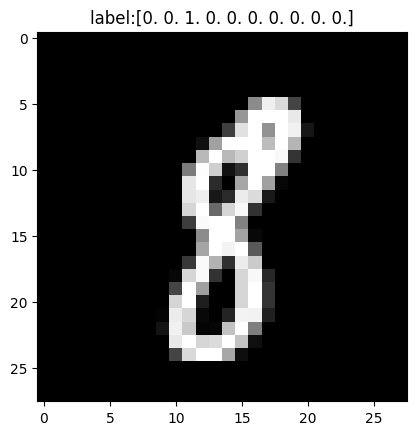

In [10]:
import matplotlib.pyplot as plt
plt.imshow(x_train[300] , cmap ="gray")
plt.title(f"label:{y_train[400]}")
plt.show()

In [14]:
model = tensorflow.keras.models.Sequential()
model.add(tensorflow.keras.layers.Conv2D(8,kernel_size=(3,3), activation="relu", input_shape=(28,28,1)))
model.add(tensorflow.keras.layers.MaxPool2D(pool_size=(2,2)))

model.add(tensorflow.keras.layers.Conv2D(16,kernel_size=(3,3), activation="relu"))
model.add(tensorflow.keras.layers.Conv2D(4,kernel_size=(3,3), activation="relu"))
model.add(tensorflow.keras.layers.MaxPool2D(pool_size=(2,2)))
model.add(tensorflow.keras.layers.Flatten())
model.add(tensorflow.keras.layers.Dense(16, activation="relu"))

model.add(tensorflow.keras.layers.Dense(10, activation="softmax"))

C:\Users\Admin\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [15]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 26, 26, 8)           │              80 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 13, 13, 8)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 11, 11, 16)          │           1,168 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 9, 9, 4)             │             580 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 4, 4, 4)             │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 16)                  │           1,040 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 10)                  │             170 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 3,038 (11.87 KB)

 Trainable params: 3,038 (11.87 KB)

 Non-trainable params: 0 (0.00 B)

In [16]:
model.compile(loss = tensorflow.keras.losses.categorical_crossentropy,
              optimizer = tensorflow.keras.optimizers.Adam(),metrics=["Accuracy"])


In [17]:
model.fit(x_train , y_train ,batch_size = 32 , epochs = 2)

Epoch 1/2
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 30s 14ms/step - Accuracy: 0.8783 - loss: 0.3856
Epoch 2/2
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 27s 15ms/step - Accuracy: 0.9589 - loss: 0.1372


In [18]:
pred = model.predict(x_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step


In [19]:
model.evaluate(x_test,y_test)


313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - Accuracy: 0.9675 - loss: 0.1015


[0.10152504593133926, 0.9674999713897705]

In [20]:
pred_class = pred.argmax(axis = 1)

In [21]:
pred_class

array([7, 2, 1, ..., 4, 5, 6], shape=(10000,))